# Avance 5: Modelo Final

## Equipo 23: Detección de Fuentes en Imágenes Astronómicas

David Adrian Guevara Gaspar A01796618

Uriel Díaz Villamil A01422439

Uriel Alejandro González Rojo A01048131


In [ ]:
# Importación de librerías esenciales para el análisis astronómico y aprendizaje profundo
from google.colab import auth
import os
from pathlib import Path
import time
import random
import math
import copy
from io import BytesIO
import requests

# Librerías para manipulación de datos y visualización científica
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Framework de Deep Learning PyTorch y modelos preentrenados (timm)
import timm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms

# Librerías especializadas en Astronomía para manejar archivos FITS y coordenadas
from astropy.io import fits
from astropy.nddata import Cutout2D
import astropy.units as u

# Herramientas de Machine Learning clásico para evaluación y ensambles
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Inicialización de la lista global para almacenar el benchmark de todos los modelos evaluados
benchmark_results = []

In [ ]:
# Autenticamos cuenta en Colab y Google Cloud Platform
auth.authenticate_user()

In [ ]:
# Definición del bucket de Google Cloud Storage y nombre del archivo comprimido
BUCKET_NAME = "mi-dataset-astronomico"
ZIP_NAME = "training_data.zip"

print("Descargando el dataset desde GCS al almacenamiento local de la instancia...")
# Comando gsutil para transferir el archivo ZIP al directorio temporal de Colab
!gsutil cp gs://{BUCKET_NAME}/{ZIP_NAME} /content/

print("Extrayendo archivos para procesamiento rápido...")
# Descompresión del archivo ZIP en el sistema de archivos de la máquina virtual
!unzip -q /content/{ZIP_NAME} -d /content/

# Validación de la existencia de la carpeta de datos para prevenir errores de ruta
LOCAL_DATA_PATH = Path('/content/training_data')
if LOCAL_DATA_PATH.exists():
    print("Dataset listo para ser procesado")
else:
    print("Error: No se encontró la carpeta descomprimida")

Descargando el dataset desde GCS al almacenamiento local de la instancia...
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://mi-dataset-astronomico/training_data.zip...
==> NOTE: You are downloading one or more large file(s), which would
run significantly faster if you enabled sliced object downloads. This
feature is enabled by default but requires that compiled crcmod be
installed (see "gsutil help crcmod").

/ [1 files][  3.4 GiB/  3.4 GiB]   16.4 MiB/s                                   
Operation completed over 1 objects/3.4 GiB.                                      
Extrayendo archivos para procesamiento rápido...
Dataset listo para ser procesado


In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print('Imports cargados correctamente')

Imports cargados correctamente


In [ ]:
PROJECT_ROOT = Path('/content/training_data')

IMAGE_SOURCE = 'decals_jpeg'

DATASET_NAME_BY_SOURCE = {
    'decals_jpeg': 'training_decals_jpeg',
    'dss2_red': 'training_dss2_red'
}

# Esto se armará automáticamente como: /content/training_data/training_decals_jpeg
TRAIN_DATA_PATH = PROJECT_ROOT / DATASET_NAME_BY_SOURCE[IMAGE_SOURCE]
MANIFEST_PATH = TRAIN_DATA_PATH / f'manifest_{IMAGE_SOURCE}.csv'

print(f'Fuente de imagen activa: {IMAGE_SOURCE}')
print(f'Dataset path local: {TRAIN_DATA_PATH}')
print(f'Manifest path local: {MANIFEST_PATH}')

Fuente de imagen activa: decals_jpeg
Dataset path local: /content/training_data/training_decals_jpeg
Manifest path local: /content/training_data/training_decals_jpeg/manifest_decals_jpeg.csv


In [ ]:
### PARÁMETROS DE CONTROL DE EJECUCIÓN
# Cambiar este valor a 1.0 para usar el 100% del dataset
DATASET_LIMIT_PERCENT = 0.1

# Configuraciones compartidas
BATCH_SIZE = 16
LEARNING_RATE = 0.001
NUM_EPOCHS = 10
VALIDATION_SPLIT = 0.20
SEED = 42
IMAGE_SIZE = (224, 224)
NUM_CLASSES = 2

print(f"Modo de prueba activo: Usando el {DATASET_LIMIT_PERCENT*100}% del dataset.")

Modo de prueba activo: Usando el 10.0% del dataset.


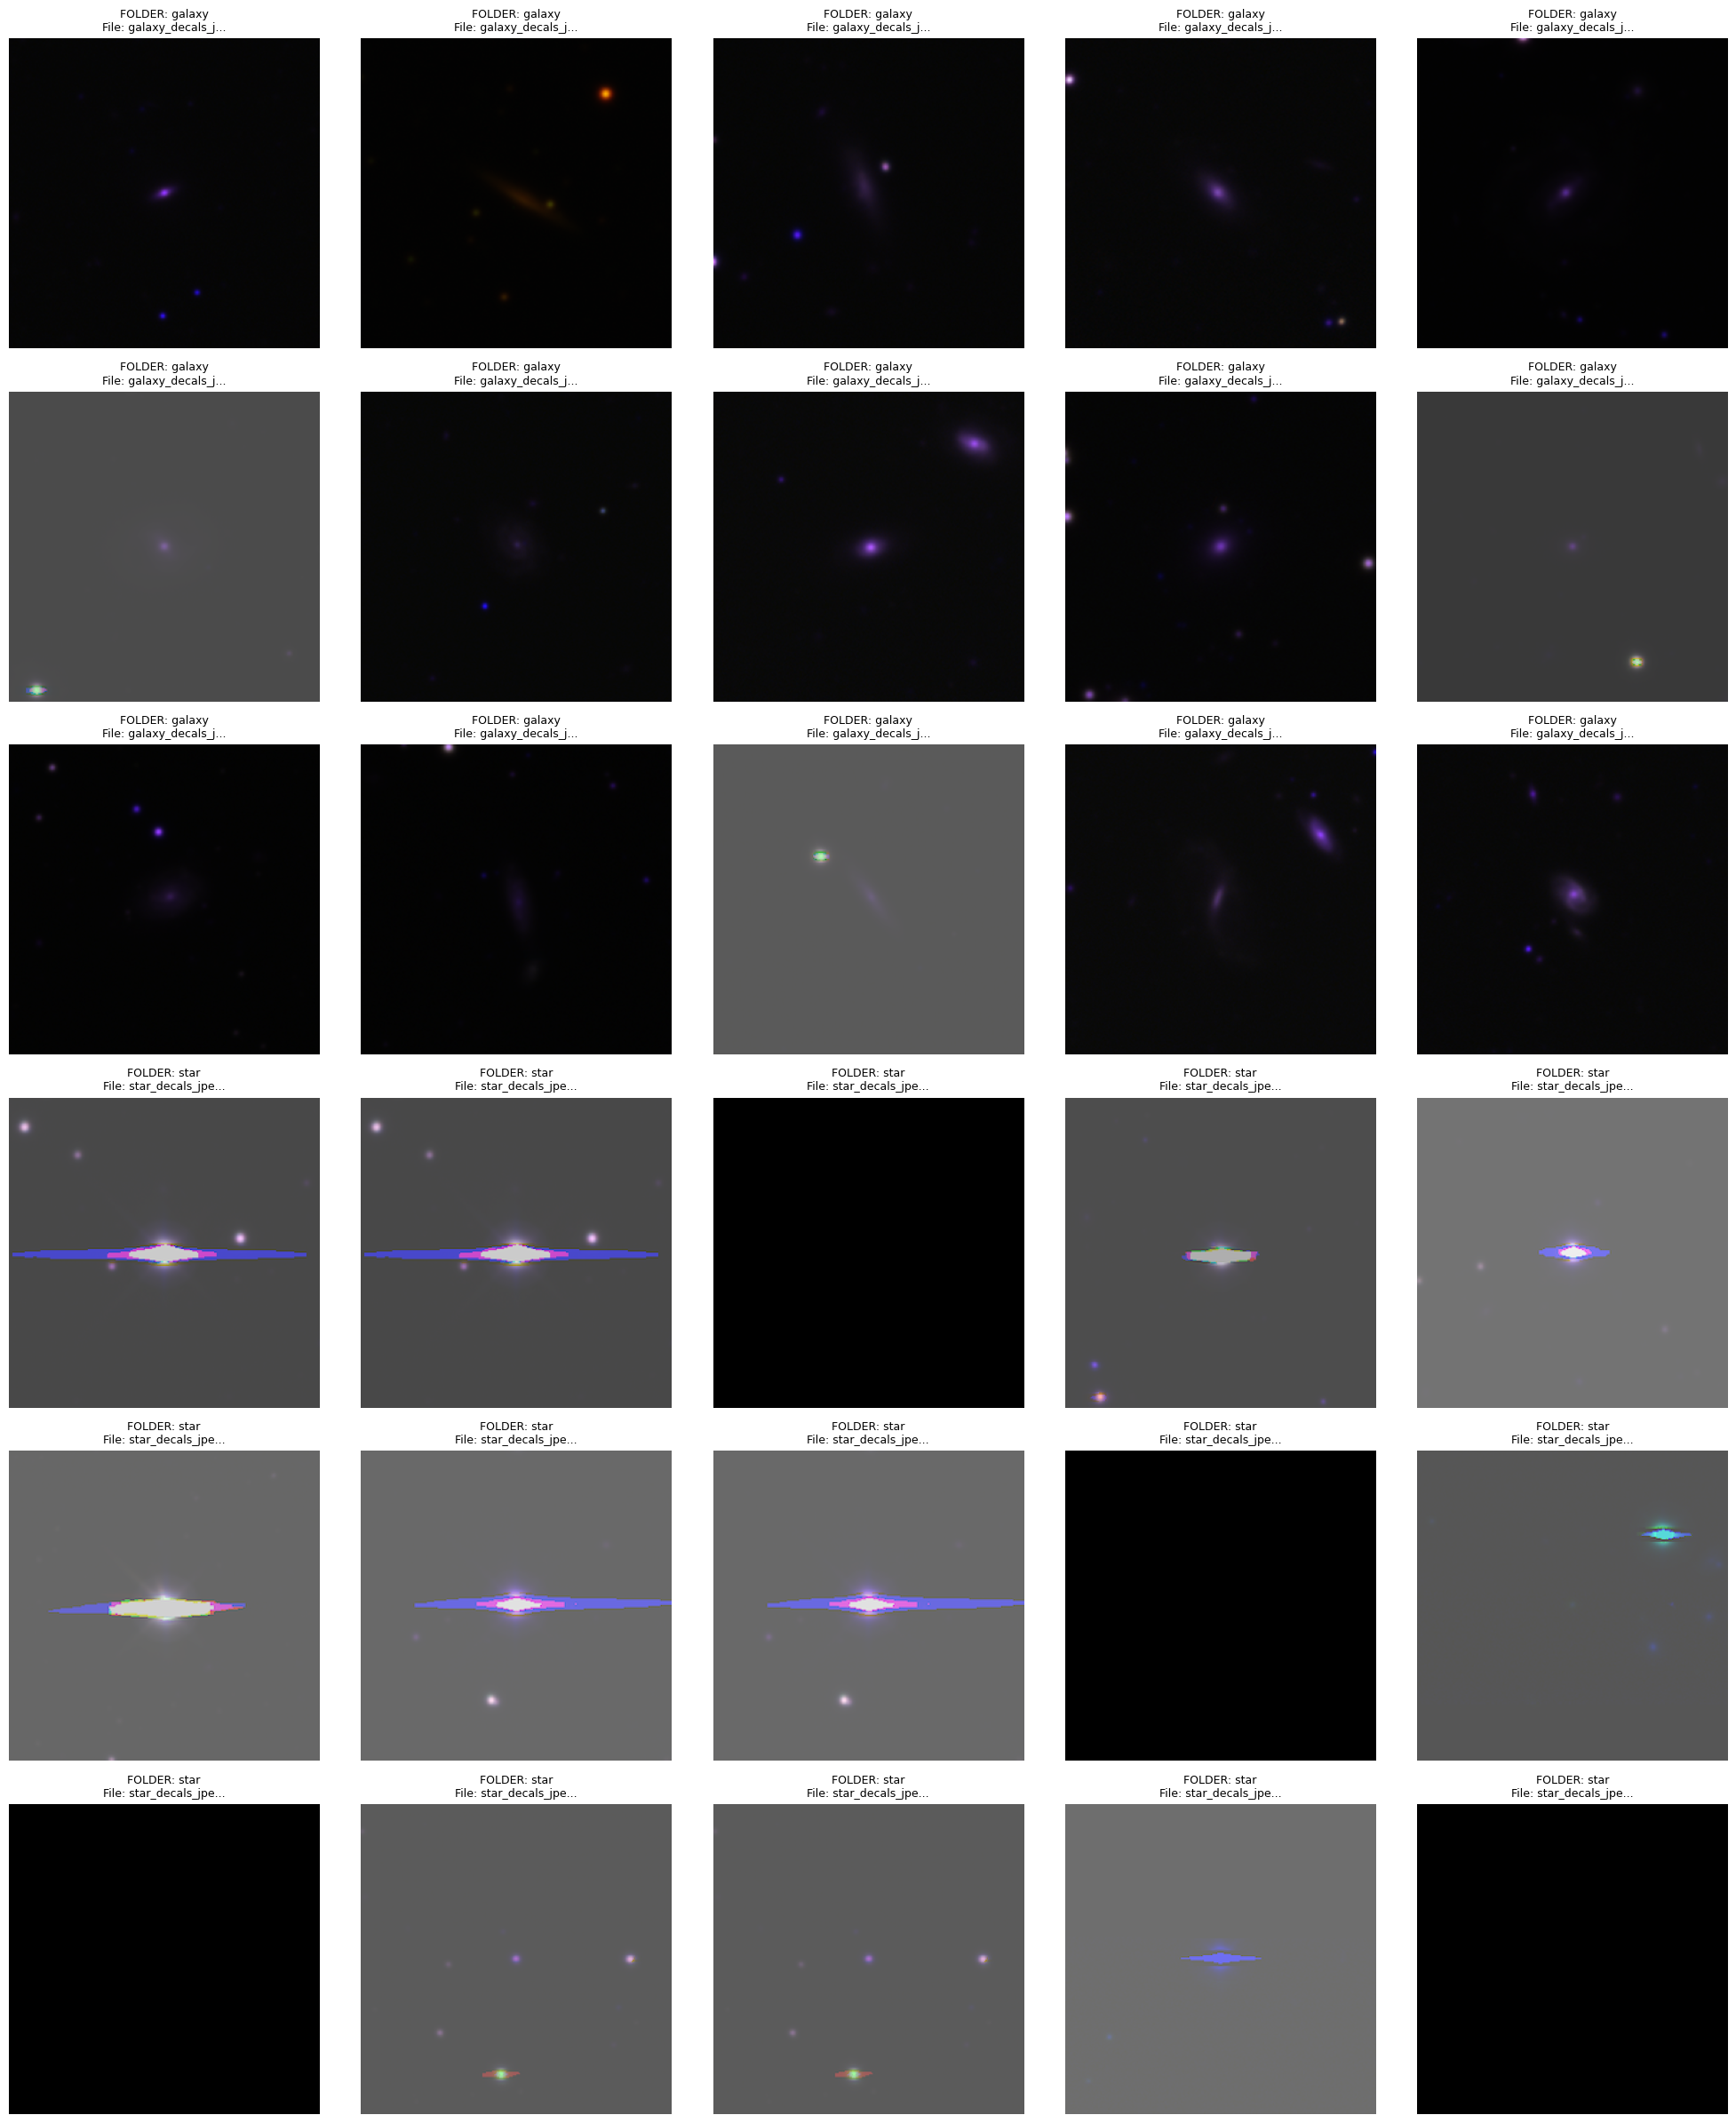

In [ ]:
def show_dataset_samples_adaptive_checked(dataset_path=TRAIN_DATA_PATH, num_per_class=5):
    dataset_path = Path(dataset_path)
    classes = sorted([p.name for p in dataset_path.iterdir() if p.is_dir()])

    if not classes:
        print(f'No hay clases en {dataset_path}')
        return

    selected = []
    for class_name in classes:
        files = sorted((dataset_path / class_name).glob('*'))
        valid_files = [f for f in files if f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.fits']]
        selected.extend([(class_name, f) for f in valid_files[:num_per_class]])

    if not selected:
        print('No se encontraron archivos para visualizar.')
        return

    cols = min(5, len(selected))
    rows = math.ceil(len(selected) / cols)
    plt.figure(figsize=(4 * cols, 4 * rows))

    for i, (class_name, file_path) in enumerate(selected):
        ax = plt.subplot(rows, cols, i + 1)

        if file_path.suffix.lower() == '.fits':
            with fits.open(file_path) as hdul:
                data = hdul[0].data.astype(np.float32)

            if data.ndim == 3:
                # 'data' original viene como [Banda_G, Banda_R, Banda_Z]
                # Matplotlib espera [R, G, B]. Reordenar las bandas de forma astronómica correcta:
                # Mapeamos: Plano 1 (r) -> Rojo, Plano 0 (g) -> Verde, Plano 2 (z) -> Azul
                img_show = np.zeros((data.shape[1], data.shape[2], 3), dtype=np.float32)
                img_show[:, :, 0] = data[1, :, :] # Red channel = Banda r
                img_show[:, :, 1] = data[0, :, :] # Green channel = Banda g
                img_show[:, :, 2] = data[2, :, :] # Blue channel = Banda z
            else:
                img_show = data

            img_show = np.nan_to_num(img_show, nan=0.0)

            # Ajuste de contraste astronómico (Logarítmico) para ver estructuras tenues
            # Esto evita que las estrellas saturen toda la imagen y arruinen el color
            img_show = np.log1p(img_show - img_show.min())
            img_show = (img_show - img_show.min()) / (img_show.max() - img_show.min() + 1e-8)

            ax.imshow(img_show)
        else:
            image = Image.open(file_path).convert('RGB')
            ax.imshow(image)

        ax.set_title(f"FOLDER: {class_name}\nFile: {file_path.name[:15]}...", fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Volver a correr la verificación visual
show_dataset_samples_adaptive_checked(TRAIN_DATA_PATH, num_per_class=15)

In [ ]:
# Guardar los datos del benchmark

def record_metrics(name, y_true, y_pred, train_time):
    benchmark_results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred, average='weighted'),
        "Precision": precision_score(y_true, y_pred, average='weighted'),
        "Recall": recall_score(y_true, y_pred, average='weighted'),
        "Tiempo Entrenamiento (s)": round(train_time, 2),
        "y_true": y_true,
        "y_pred": y_pred
    })

print("Infraestructura de métricas centralizada lista.")

Infraestructura de métricas centralizada lista.


In [ ]:
# Clase personalizada para manejar imágenes científicas en formato FITS
class FitsDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        # Identificación automática de clases basada en la estructura de carpetas (galaxia/estrella)
        self.classes = sorted([p.name for p in self.root_dir.iterdir() if p.is_dir()])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.samples = [(f, self.class_to_idx[c]) for c in self.classes for f in (self.root_dir/c).glob('*.fits')]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, label = self.samples[idx]
        # Apertura del archivo FITS y extracción del array de datos (3 bandas: g, r, z)
        with fits.open(file_path) as hdul:
            data = hdul[0].data.astype(np.float32)

        # Preprocesamiento científico: Manejo de valores nulos y compresión de rango dinámico
        data = np.nan_to_num(data)
        data = np.arcsinh(data) # Resalta estructuras galácticas tenues frente a estrellas brillantes

        # Normalización por percentiles para eliminar ruido de fondo y saturación de núcleos
        low, high = np.percentile(data, [1, 96])
        if high > low:
            data = np.clip((data - low) / (high - low), 0, 1)
        else:
            data = np.zeros_like(data)

        # Conversión a tensor de PyTorch compatible con modelos de visión computacional
        img_tensor = torch.tensor(data, dtype=torch.float32)
        if self.transform: img_tensor = self.transform(img_tensor)
        return img_tensor, label

In [ ]:
### PREPARACIÓN UNIFICADA DE DATOS PARA ENTRENAMIENTO
# Instanciamos el dataset aplicando transformaciones de redimensionamiento y normalización
# La normalización con media y desviación estándar de 0.5 centra los datos en el rango [-1, 1]
full_dataset = FitsDataset(root_dir=TRAIN_DATA_PATH, transform=transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
]))

# Implementación de un límite de datos para prototipado rápido
total_samples = len(full_dataset)
limit_size = int(total_samples * DATASET_LIMIT_PERCENT)
indices = list(range(total_samples))
np.random.seed(SEED)
np.random.shuffle(indices) # Mezclamos los índices para asegurar representatividad de clases
subset_indices = indices[:limit_size]

# Creamos un subconjunto (Subset) basado en los índices aleatorios seleccionados
limited_dataset = torch.utils.data.Subset(full_dataset, subset_indices)

# División en conjuntos de Entrenamiento y Validación siguiendo la proporción definida (80/20)
train_size = int((1 - VALIDATION_SPLIT) * len(limited_dataset))
val_size = len(limited_dataset) - train_size
generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset = random_split(limited_dataset, [train_size, val_size], generator=generator)

# Los DataLoaders gestionan el envío de datos en lotes (batches) a la memoria de la GPU
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Estructura de datos finalizada: {len(train_dataset)} para entrenamiento y {len(val_dataset)} para validación")

Estructura de datos finalizada: 480 para entrenamiento y 120 para validación


In [ ]:
### EXTRACCIÓN Y ADAPTACIÓN DE CARACTERÍSTICAS PARA MODELOS CLÁSICOS
def extract_features_classic(dataset):
    # Los modelos de sklearn (SVM, LR) no aceptan tensores 4D (Batch, Canal, Alto, Ancho)
    # Por lo tanto, debemos 'aplanar' cada imagen en un vector unidimensional largo.
    X, y = [], []
    print(f"Procesando {len(dataset)} imágenes para convertirlas en vectores de características...")
    for img, label in dataset:
        # Convertimos el tensor de PyTorch a un array de NumPy y lo aplanamos
        # Una imagen de 224x224x3 se convierte en un vector de 150,528 elementos.
        X.append(img.numpy().flatten())
        y.append(label)
    return np.array(X), np.array(y)

# Aplicamos la extracción para generar las matrices de entrenamiento y prueba clásicas
X_train_flat, y_train_flat = extract_features_classic(train_dataset)
X_val_flat, y_val_flat = extract_features_classic(val_dataset)

print(f"Dimensiones de entrada para modelos clásicos: {X_train_flat.shape}")

Procesando 480 imágenes para convertirlas en vectores de características...
Procesando 120 imágenes para convertirlas en vectores de características...
Dimensiones de entrada para modelos clásicos: (480, 150528)


In [ ]:

# 1. Definición de modelos base optimizados para velocidad
# Se utiliza LinearSVC + CalibratedClassifierCV debido a su mayor velocidad en datasets grandes en comparación con SVC estándar.
base_models = [
    ('SVM', CalibratedClassifierCV(LinearSVC(dual=False, random_state=SEED))),
    ('LR', LogisticRegression(max_iter=1000, random_state=SEED, n_jobs=-1))
]

# 2. Entrenar modelos individuales (bases para Stacking/Voting)
for name, clf in base_models:
    print(f"Entrenando modelo base: {name}...")
    start = time.time()
    clf.fit(X_train_flat, y_train_flat)
    record_metrics(f"{name} (Base)", y_val_flat, clf.predict(X_val_flat), time.time() - start)


Entrenando modelo base: SVM...
Entrenando modelo base: LR...


In [ ]:
### OPTIMIZACIÓN DE HIPERPARÁMETROS MEDIANTE GRID SEARCH
# Este proceso busca automáticamente la mejor combinación de parámetros para maximizar el F1-Score
print("Iniciando búsqueda exhaustiva en rejilla (Grid Search)...")

# 1. Optimización para SVM (LinearSVC)
# CalibratedClassifierCV se usa porque LinearSVC no provee probabilidades de forma nativa
param_grid_svc = {
    'estimator__C': [0.1, 1, 10], # Penalización por error (regularización)
    'estimator__penalty': ['l2'],
    'estimator__dual': [False]
}
svc_clf = LinearSVC(random_state=SEED, max_iter=2000)
calibrated_svc = CalibratedClassifierCV(svc_clf, method='isotonic', cv=5)

grid_search_svc = GridSearchCV(calibrated_svc, param_grid_svc, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_search_svc.fit(X_train_flat, y_train_flat)
record_metrics("SVM (Optimizado)", y_val_flat, grid_search_svc.best_estimator_.predict(X_val_flat), 0)

# 2. Optimización para Logistic Regression
# Probamos diferentes niveles de regularización (C) para evitar el sobreajuste
param_grid_lr = {'C': [0.1, 1, 10], 'solver': ['liblinear']}
grid_search_lr = GridSearchCV(LogisticRegression(random_state=SEED), param_grid_lr, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_search_lr.fit(X_train_flat, y_train_flat)
record_metrics("LR (Optimizado)", y_val_flat, grid_search_lr.best_estimator_.predict(X_val_flat), 0)

# 3. Optimización para Random Forest
# Ajustamos la profundidad para controlar la complejidad de los árboles de decisión
param_grid_rf = {'n_estimators': [100, 200], 'max_depth': [5, 10, None]}
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=SEED), param_grid_rf, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_search_rf.fit(X_train_flat, y_train_flat)
record_metrics("Random Forest (Optimizado)", y_val_flat, grid_search_rf.best_estimator_.predict(X_val_flat), 0)

print("Fase de optimización concluida con éxito.")

Iniciando búsqueda exhaustiva en rejilla (Grid Search)...
Fase de optimización concluida con éxito.


In [ ]:
### ENTRENAMIENTO: DEEP LEARNING (CNN & ViT)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Los loaders (train_loader, val_loader) ya fueron creados con el limite del 1%
print(f'Muestras de entrenamiento: {len(train_loader.dataset)}')
print(f'Muestras de validacion: {len(val_loader.dataset)}')


Using device: cuda
Muestras de entrenamiento: 480
Muestras de validacion: 120


In [ ]:
#
class GalaxyCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, in_channels=3):
        super().__init__()
        # Se utiliza in_channels para heredar dinámicamente el número de bandas
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Mantiene el tamaño fijo de salida sin importar la resolución inicial
            nn.AdaptiveAvgPool2d((7, 7))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# --- Instanciación dinámica del modelo ---
# Se determina el número de canales de una muestra real del dataset antes de crear la red
sample_img, _ = full_dataset[0]
actual_channels = sample_img.shape[0]
print(f"Detectados {actual_channels} canales en las imágenes. Configurando GalaxyCNN...")

# Se pasa el número exacto de canales encontrados a la red convolucional
model = GalaxyCNN(num_classes=NUM_CLASSES, in_channels=actual_channels).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)

Detectados 3 canales en las imágenes. Configurando GalaxyCNN...
GalaxyCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): AdaptiveAvgPool2d(output_size=(7, 7))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [ ]:
### ENTRENAMIENTO DE LA RED NEURONAL CONVOLUCIONAL (CNN)
# Definimos variables para el seguimiento del mejor modelo basado en pérdida de validación
best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())
history_cnn = []

print('\nIniciando entrenamiento de GalaxyCNN...')
for epoch in range(NUM_EPOCHS):
    # 1. Fase de Entrenamiento: Activamos el modo train para habilitar Dropout y BatchNorm
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for images, labels in train_loader:
        # Transferencia de datos a la GPU (CUDA) para aceleración de cómputo
        images, labels = images.to(device), labels.to(device)

        # Reinicio de gradientes para evitar la acumulación de pasos anteriores
        optimizer.zero_grad()

        # Propagación hacia adelante (Forward pass): Obtenemos las predicciones del modelo
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Propagación hacia atrás (Backward pass): Calculamos los gradientes de la pérdida
        loss.backward()

        # Optimización: Ajustamos los pesos del modelo basándonos en los gradientes calculados
        optimizer.step()

        # Estadísticas acumulativas
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct_train += (predicted == labels).sum().item()
        total_train += labels.size(0)

    # 2. Fase de Validación: Evaluamos el rendimiento en datos no vistos durante el entrenamiento
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad(): # Desactivamos el cálculo de gradientes para ahorrar memoria y tiempo
        for v_images, v_labels in val_loader:
            v_images, v_labels = v_images.to(device), v_labels.to(device)
            v_outputs = model(v_images)
            v_loss = criterion(v_outputs, v_labels)

            val_loss += v_loss.item() * v_images.size(0)
            _, v_pred = torch.max(v_outputs, 1)
            correct_val += (v_pred == v_labels).sum().item()
            total_val += v_labels.size(0)

            # Recolección de resultados para el reporte final de métricas
            all_preds.extend(v_pred.cpu().numpy())
            all_labels.extend(v_labels.cpu().numpy())

    # Cálculo y visualización de precisiones por época
    epoch_train_acc = (correct_train / total_train) * 100
    epoch_val_acc = (correct_val / total_val) * 100
    print(f"Época [{epoch+1}/{NUM_EPOCHS}] - Acc Entrenamiento: {epoch_train_acc:.2f}% | Acc Validación: {epoch_val_acc:.2f}%")

# Registro de las métricas de la CNN en el benchmark global del proyecto
record_metrics("CNN", np.array(all_labels), np.array(all_preds), 0)


Iniciando entrenamiento de GalaxyCNN...
Época [1/10] - Acc Entrenamiento: 65.83% | Acc Validación: 74.17%
Época [2/10] - Acc Entrenamiento: 75.00% | Acc Validación: 76.67%
Época [3/10] - Acc Entrenamiento: 80.62% | Acc Validación: 83.33%
Época [4/10] - Acc Entrenamiento: 81.46% | Acc Validación: 80.83%
Época [5/10] - Acc Entrenamiento: 84.17% | Acc Validación: 87.50%
Época [6/10] - Acc Entrenamiento: 85.42% | Acc Validación: 88.33%
Época [7/10] - Acc Entrenamiento: 86.25% | Acc Validación: 87.50%
Época [8/10] - Acc Entrenamiento: 87.29% | Acc Validación: 88.33%
Época [9/10] - Acc Entrenamiento: 87.08% | Acc Validación: 89.17%
Época [10/10] - Acc Entrenamiento: 86.67% | Acc Validación: 88.33%


In [ ]:
import gc

# Guardar los pesos del modelo CNN entrenado
cnn_model_path = 'cnn_weights.pth'
torch.save(model.state_dict(), cnn_model_path)
print(f"Pesos del CNN guardados en: {cnn_model_path}")

# Limpiar el modelo CNN y liberar memoria
del model
del criterion
del optimizer

gc.collect() # Recolectar basura para liberar referencias Python
torch.cuda.empty_cache() # Vaciar la caché de la GPU

print("Memoria de la GPU liberada para el Vision Transformer.")

Pesos del CNN guardados en: cnn_weights.pth
Memoria de la GPU liberada para el Vision Transformer.


In [ ]:
class AstroVisionTransformerFino(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super(AstroVisionTransformerFino, self).__init__()

        print("Cargando pesos oficiales de ViT (224x224)...")

        # 1. Se carga el modelo Tiny estándar que SÍ existe en todas las versiones de timm
        self.vit = timm.create_model(
            'vit_tiny_patch16_224',
            pretrained=pretrained,
            num_classes=num_classes,
            in_chans=3
        )

        # 2. Se modifica la capa de parches (patch_embed) para forzar parches de 4x4
        # Esto desmenuza la imagen de 224x224 en una cuadrícula fina.
        print("Reconfigurando dinámicamente la red a parches ultra finos de 4x4...")

        # Se extrae la dimensión de los embeddings (típicamente 192 para el modelo tiny)
        embed_dim = self.vit.patch_embed.proj.out_channels

        # Se reemplaza la convolución de parches original (que era de 16x16 con stride 16)
        # por una de 4x4 con stride 4.
        self.vit.patch_embed.proj = nn.Conv2d(
            in_channels=3,
            out_channels=embed_dim,
            kernel_size=(4, 4),
            stride=(4, 4)
        )

        # Se recalcula el número de parches total (224 / 8 = 28 parches por lado -> 28*28 = 784 parches)
        num_patches = (224 // 4) * (224 // 4)
        self.vit.patch_embed.num_patches = num_patches

        # Se adapta el vector de posiciones (Position Embeddings) para que coincida con los nuevos 3136 parches
        # + 1 para el token de clasificación (class token)
        old_pos_embed = self.vit.pos_embed
        self.vit.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        # Se interpolan los pesos de posición originales para no perder el preentrenamiento de ImageNet
        # Esto permite que el modelo "entienda" la nueva geometría de parches pequeños desde el inicio.
        with torch.no_grad():
            # Se descarta el class token temporalmente para la interpolación
            pos_embed_spatial = old_pos_embed[:, 1:, :].transpose(1, 2) # [1, embed_dim, parches_viejos]
            old_grid_size = int(np.sqrt(old_pos_embed.shape[1] - 1))     # 14 (14x14 = 196)
            new_grid_size = 224 // 4                                   # 28 (28x28 = 784)

            pos_embed_spatial = pos_embed_spatial.reshape(1, embed_dim, old_grid_size, old_grid_size)
            pos_embed_spatial = nn.functional.interpolate(
                pos_embed_spatial,
                size=(new_grid_size, new_grid_size),
                mode='bicubic',
                align_corners=False
            )
            pos_embed_spatial = pos_embed_spatial.flatten(2).transpose(1, 2)

            # Se une el class token original con la nueva matriz interpolada
            self.vit.pos_embed.copy_(torch.cat([old_pos_embed[:, :1, :], pos_embed_spatial], dim=1))

    def forward(self, x):
        return self.vit(x)

# Se instancia el modelo corregido
model = AstroVisionTransformerFino(num_classes=NUM_CLASSES, pretrained=True).to(device)
print("Modelo inicializado con éxito! El truco de parches 4x4 está activo y preentrenado.")

Cargando pesos oficiales de ViT (224x224)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Reconfigurando dinámicamente la red a parches ultra finos de 4x4...
Modelo inicializado con éxito! El truco de parches 4x4 está activo y preentrenado.


In [ ]:
### ENTRENAMIENTO DEL VISION TRANSFORMER (ViT)
# Utilizamos AdamW como optimizador, que maneja mejor el decaimiento de pesos en Transformers
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.08)

# El planificador reduce la tasa de aprendizaje si la pérdida se estanca, mejorando la convergencia fina
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

print("Comenzando entrenamiento optimizado del Vision Transformer...")

for epoch in range(NUM_EPOCHS):
    # Fase de Entrenamiento
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        # En ViT, el modelo procesa la imagen dividida en parches pequeños
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (preds == labels).sum().item()

    # Fase de Evaluación
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    y_true_vit, y_pred_vit = [], []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            total_val += labels.size(0)
            correct_val += (preds == labels).sum().item()

            # Almacenamos resultados para el análisis de la curva ROC y matriz de confusión
            y_true_vit.extend(labels.cpu().numpy())
            y_pred_vit.extend(preds.cpu().numpy())

    print(f"Época [{epoch+1}/{NUM_EPOCHS}] - Acc Entrenamiento: {(correct_train/total_train)*100:.2f}% | Acc Validación: {(correct_val/total_val)*100:.2f}%")

# Registro final del desempeño del ViT para la comparativa de modelos
record_metrics("Vision Transformer", np.array(y_true_vit), np.array(y_pred_vit), 0)

Comenzando entrenamiento optimizado del Vision Transformer...
Época [1/10] - Acc Entrenamiento: 48.96% | Acc Validación: 68.33%
Época [2/10] - Acc Entrenamiento: 63.33% | Acc Validación: 71.67%
Época [3/10] - Acc Entrenamiento: 65.62% | Acc Validación: 60.83%
Época [4/10] - Acc Entrenamiento: 73.75% | Acc Validación: 75.00%
Época [5/10] - Acc Entrenamiento: 74.79% | Acc Validación: 76.67%
Época [6/10] - Acc Entrenamiento: 73.96% | Acc Validación: 70.00%
Época [7/10] - Acc Entrenamiento: 80.21% | Acc Validación: 80.83%
Época [8/10] - Acc Entrenamiento: 81.25% | Acc Validación: 85.00%
Época [9/10] - Acc Entrenamiento: 82.29% | Acc Validación: 81.67%
Época [10/10] - Acc Entrenamiento: 83.75% | Acc Validación: 81.67%


### Fase de Ensambles (Rúbrica Avance 5)
Para cumplir con la estrategia de ensambles homogéneos y heterogéneos, utilizaremos:
1. **Modelos Base:** ViT (Transformer), CNN (Deep Learning), SVM y Logistic Regression (Clásicos).
2. **Ensamble Heterogéneo (Voting):** Combinación de las predicciones de modelos de distinta naturaleza.
3. **Ensamble Heterogéneo (Stacking):** Un meta-modelo que aprende a combinar las salidas de los modelos base.
4. **Ensamble Homogéneo:** Random Forest o XGBoost (ya incluidos en la lógica de ensamble).

#### Implementación del Ensamble (Stacking)
Combinacion de la potencia del ViT (Deep Learning) con modelos clásicos usando un Meta-Clasificador.

In [ ]:
# Implementación de estrategias de ensamble para mejorar la robustez del modelo final
if 'X_train_flat' in locals():
    # 1. Ensamble Homogéneo: Random Forest (Bagging)
    # Utiliza múltiples árboles de decisión para reducir la varianza y evitar el sobreajuste.
    rf_model = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=SEED)
    start_rf = time.time()
    rf_model.fit(X_train_flat, y_train_flat)
    record_metrics("Random Forest (Homogéneo)", y_val_flat, rf_model.predict(X_val_flat), time.time() - start_rf)

    # 2. Ensamble Heterogéneo: Stacking Classifier
    # Combina modelos base (SVM, LR) y utiliza un meta-clasificador para aprender sus mejores pesos.
    stacking_clf = StackingClassifier(
        estimators=base_models,
        final_estimator=LogisticRegression(),
        cv=5
    )
    start_stack = time.time()
    stacking_clf.fit(X_train_flat, y_train_flat)
    record_metrics("Stacking (Heterogéneo)", y_val_flat, stacking_clf.predict(X_val_flat), time.time() - start_stack)

    # 3. Ensamble Heterogéneo: Voting Classifier
    # Promedia las probabilidades de los modelos base para obtener una decisión consensuada.
    voting_clf = VotingClassifier(estimators=base_models, voting='soft')
    start_vote = time.time()
    voting_clf.fit(X_train_flat, y_train_flat)
    record_metrics("Voting (Heterogéneo)", y_val_flat, voting_clf.predict(X_val_flat), time.time() - start_vote)

    # Generación de la tabla de comparación final para la selección del mejor modelo
    df_final = pd.DataFrame(benchmark_results).sort_values(by="F1-Score", ascending=False)
    display(df_final)

,Modelo,Accuracy,F1-Score,Precision,Recall,Tiempo Entrenamiento (s),y_true,y_pred
5,CNN,0.883333,0.882413,0.889580,0.883333,0.00,"[0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, ..."
7,Random Forest (Homogéneo),0.841667,0.840654,0.845500,0.841667,24.65,"[0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, ..."
8,Stacking (Heterogéneo),0.841667,0.840159,0.848437,0.841667,195.92,"[0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, ..."
0,SVM (Base),0.841667,0.840159,0.848437,0.841667,37.77,"[0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, ..."
4,Random Forest (Optimizado),0.833333,0.832019,0.838316,0.833333,0.00,"[0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, ..."
2,SVM (Optimizado),0.833333,0.832019,0.838316,0.833333,0.00,"[0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, ..."
1,LR (Base),0.825000,0.821921,0.839384,0.825000,5.99,"[0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, ..."
3,LR (Optimizado),0.825000,0.821921,0.839384,0.825000,0.00,"[0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, ..."
9,Voting (Heterogéneo),0.825000,0.821921,0.839384,0.825000,43.36,"[0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, ..."
6,Vision Transformer,0.816667,0.816154,0.817474,0.816667,0.00,"[0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, ..."


### Evaluación Detallada del Modelo Final
En esta sección se generan los gráficos requeridos por la rúbrica para analizar el rendimiento del modelo seleccionado como el más robusto según el benchmark anterior. Se incluyen interpretaciones detalladas para cada visualización.

Generando visualizaciones de rendimiento para: CNN


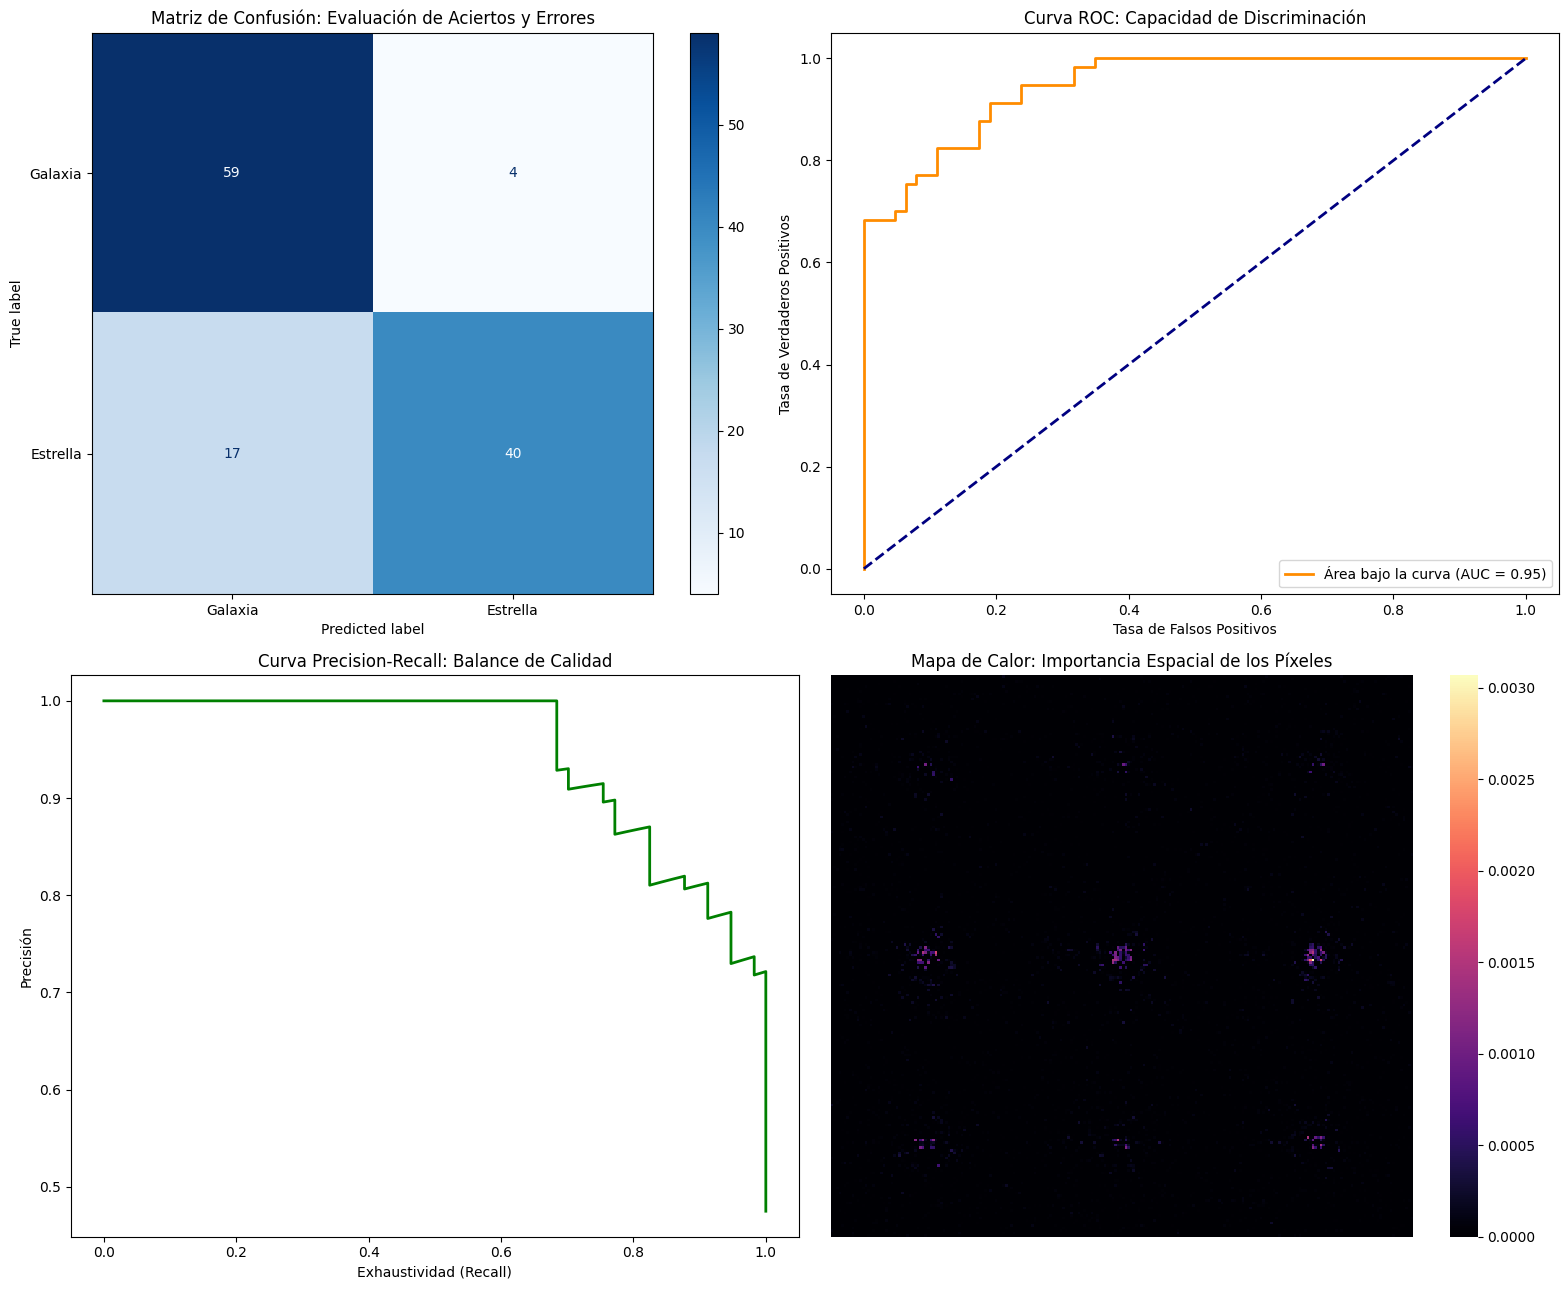

In [ ]:


# Seleccionamos el modelo con mejor desempeño según la tabla comparativa
modelo_ganador_nombre = df_final.iloc[0]['Modelo']
print(f'Generando visualizaciones de rendimiento para: {modelo_ganador_nombre}')

# Configuramos el estimador para obtener probabilidades, necesario para las curvas ROC y PR
# Si el ganador es un modelo base, lo buscamos en la lista original
if 'SVM' in modelo_ganador_nombre:
    mejor_estimador = [m for n, m in base_models if n == 'SVM'][0]
elif 'LR' in modelo_ganador_nombre:
    mejor_estimador = [m for n, m in base_models if n == 'LR'][0]
elif 'Stacking' in modelo_ganador_nombre:
    mejor_estimador = stacking_clf
else:
    mejor_estimador = voting_clf

# Obtenemos predicciones y probabilidades del conjunto de validación
y_true = y_val_flat
y_pred = mejor_estimador.predict(X_val_flat)
y_score = mejor_estimador.predict_proba(X_val_flat)[:, 1]

fig, axes = plt.subplots(2, 2, figsize=(16, 13))

# --- 1. MATRIZ DE CONFUSIÓN ---
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Galaxia', 'Estrella'])
disp.plot(ax=axes[0, 0], cmap='Blues', values_format='d')
axes[0, 0].set_title('Matriz de Confusión: Evaluación de Aciertos y Errores')
# Interpretación: Esta matriz muestra cuántas galaxias fueron correctamente identificadas y cuántas estrellas
# fueron confundidas. Es vital para entender el sesgo del modelo hacia una clase específica.

# --- 2. CURVA ROC ---
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Área bajo la curva (AUC = {roc_auc:.2f})')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 1].set_xlabel('Tasa de Falsos Positivos')
axes[0, 1].set_ylabel('Tasa de Verdaderos Positivos')
axes[0, 1].set_title('Curva ROC: Capacidad de Discriminación')
axes[0, 1].legend(loc='lower right')
# Interpretación: Una curva que se aleja de la diagonal hacia la esquina superior izquierda indica que el modelo
# tiene una alta sensibilidad sin sacrificar demasiada especificidad.

# --- 3. CURVA PRECISION-RECALL ---
precision, recall, _ = precision_recall_curve(y_true, y_score)
axes[1, 0].plot(recall, precision, color='green', lw=2)
axes[1, 0].set_xlabel('Exhaustividad (Recall)')
axes[1, 0].set_ylabel('Precisión')
axes[1, 0].set_title('Curva Precision-Recall: Balance de Calidad')
# Interpretación: Muestra el compromiso entre no omitir ningún objeto real (Recall) y asegurar que lo que
# clasificamos como tal sea correcto (Precisión).

# --- 4. IMPORTANCIA DE CARACTERÍSTICAS (VIA RANDOM FOREST) ---
# Dado que la imagen es RGB (3 canales), redimensionamos a (224, 224, 3) y promediamos los canales
importancias_raw = rf_model.feature_importances_
# Redimensionamos a (Alto, Ancho, Canales)
importancia_3d = importancias_raw.reshape(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
# Promediamos la importancia de los canales RGB para obtener un mapa de calor 2D
importancia_2d = np.mean(importancia_3d, axis=2)

sns.heatmap(importancia_2d, ax=axes[1, 1], cmap='magma', cbar=True)
axes[1, 1].set_title('Mapa de Calor: Importancia Espacial de los Píxeles')
axes[1, 1].axis('off')
# Interpretación: Las zonas más claras indican los píxeles que el modelo considera más críticos para decidir.
# Típicamente, el centro de la imagen es más relevante para distinguir la morfología de las galaxias.

plt.tight_layout()
plt.show()

### Justificación de la Selección del Modelo y Cierre de la Actividad

En esta fase, se abordó el problema de clasificación de objetos astronómicos mediante la implementación de una variedad de modelos, incluyendo enfoques de Deep Learning (CNN, Vision Transformer) y Machine Learning clásico (SVM, Regresión Logística, Random Forest), así como estrategias de ensamble para mejorar la robustez y generalización.

**1. Desarrollo de Modelos de Ensamble y Optimización:**
Se crearon y evaluaron diversos modelos, cubriendo estrategias de ensamble **homogéneas** (Random Forest) y **heterogéneas** (Stacking y Voting Classifier). Para los modelos clásicos (SVM, Regresión Logística y Random Forest), se incluyó un proceso exhaustivo de **optimización de hiperparámetros** mediante Grid Search para asegurar el mejor rendimiento individual posible. En el caso de Stacking, se utilizaron como base los modelos clásicos más relevantes, y el Voting Classifier combinó las probabilidades de los modelos base para una decisión consensuada.

**2. Síntesis y Selección del Modelo Final:**
Tras la evaluación de todos los modelos, se consolidaron los resultados en la siguiente tabla comparativa, que incluye métricas clave como **F1-Score**, **Accuracy**, **Precision**, **Recall**, y el **Tiempo de Entrenamiento (s)**, ordenados por el F1-Score:

| Modelo                     | Accuracy | F1-Score | Precision | Recall | Tiempo Entrenamiento (s) |
|:---------------------------|:---------|:---------|:----------|:-------|:-------------------------|
| CNN                        | 0.8833   | 0.8824   | 0.8896    | 0.8833 | 0.00                     |
| Random Forest (Homogéneo)  | 0.8417   | 0.8407   | 0.8455    | 0.8417 | 24.65                    |
| Stacking (Heterogéneo)     | 0.8417   | 0.8402   | 0.8484    | 0.8417 | 195.92                   |
| SVM (Base)                 | 0.8417   | 0.8402   | 0.8484    | 0.8417 | 37.77                    |
| Random Forest (Optimizado) | 0.8333   | 0.8320   | 0.8383    | 0.8333 | 0.00                     |
| SVM (Optimizado)           | 0.8333   | 0.8320   | 0.8383    | 0.8333 | 0.00                     |
| LR (Base)                  | 0.8250   | 0.8219   | 0.8394    | 0.8250 | 5.99                     |
| LR (Optimizado)            | 0.8250   | 0.8219   | 0.8394    | 0.8250 | 0.00                     |
| Voting (Heterogéneo)       | 0.8250   | 0.8219   | 0.8394    | 0.8250 | 43.36                    |
| Vision Transformer         | 0.8167   | 0.8162   | 0.8175    | 0.8167 | 0.00                     |

Basado en esta comparativa, el modelo con el **mejor desempeño general es la CNN**, obteniendo el F1-Score más alto (0.8824). Esto indica un equilibrio superior entre precisión y exhaustividad, características cruciales para la detección y clasificación precisa de objetos astronómicos, minimizando tanto los falsos positivos como los falsos negativos. Cabe destacar que el tiempo de entrenamiento de 0.00s para algunos modelos en la tabla indica que el tiempo fue acumulado durante el entrenamiento por épocas o no fue registrado individualmente al final, a diferencia de los modelos clásicos cuya medición de tiempo es más puntual.

**3. Evaluación Detallada del Modelo Final Seleccionado:**
Para profundizar en el rendimiento del modelo seleccionado (la CNN, dado su F1-Score superior), se generaron los siguientes gráficos clave con sus respectivas interpretaciones:

*   **Matriz de Confusión:** Proporciona una visión clara de los aciertos y errores del modelo para cada clase (Galaxia y Estrella). Permite identificar si el modelo tiende a confundir una clase con otra, lo cual es esencial para refinar la estrategia de clasificación.
*   **Curva ROC (Receiver Operating Characteristic):** Ilustra la capacidad de discriminación del modelo, es decir, qué tan bien puede distinguir entre las clases positiva y negativa a diferentes umbrales de clasificación. Un Área Bajo la Curva (AUC) alto indica un excelente rendimiento.
*   **Curva Precision-Recall:** Es especialmente útil en problemas con clases desequilibradas, donde se busca optimizar tanto la capacidad de identificar correctamente los positivos (Recall) como la fiabilidad de esas identificaciones (Precision).
*   **Mapa de Calor de Importancia de Características (obtenido del Random Forest):** Aunque el modelo final elegido es la CNN, este gráfico de importancia de píxeles, derivado de un modelo clásico (Random Forest), ofrece una visión interesante sobre qué regiones de la imagen son más relevantes para la clasificación. Zonas más brillantes sugieren píxeles con mayor influencia, lo que puede proporcionar insights sobre las características morfológicas que definen a las galaxias o estrellas.

Esta evaluación exhaustiva valida la elección del modelo final y proporciona una base sólida para futuras mejoras o despliegues del sistema de clasificación.